# NVIDIA HMM Journey Analysis v2

This notebook builds on the full-data HMM outputs and creates the analysis-ready bridge between HMM weekly behavior states, HDBSCAN V11 lifecycle clusters, journey archetypes, transition interpretation, and presentation-ready visuals.

Main update from the first HMM analysis pass: state labels are refined so they describe weekly behavior, not permanent lifecycle identity. HDBSCAN remains the long-term lifecycle cohort, while HMM describes recent or sequential behavior.

## 0. Setup

In [1]:
import duckdb
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

DB_PATH = "developer_project.duckdb"
OUTPUT_DIR = Path("hmm_analysis_outputs_v2")
OUTPUT_DIR.mkdir(exist_ok=True)

con = duckdb.connect(DB_PATH)

HMM_WEEKLY = "dev_hmm_weekly_states_v1"
HMM_STATE_PROFILE = "dev_hmm_state_profile_v1"
HDBSCAN_FINAL = "dev_lifecycle_cluster_membership_v11_final"
HMM_JOURNEY = "dev_hmm_developer_journey_v1"
HMM_TRANSITION = "dev_hmm_transition_matrix_v1"

NVIDIA_GREEN = "#76B900"
PALETTE = {
    "active": "#76B900",
    "cooling": "#F4B400",
    "at_risk": "#DB4437",
    "dormant": "#5F6368",
    "unactivated": "#B0BEC5",
}

plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

print("Connected to", DB_PATH)
print("Output directory:", OUTPUT_DIR.resolve())

Connected to developer_project.duckdb
Output directory: /Users/navsanya/Desktop/Spring2026_IndustryProject/hmm_analysis_outputs_v2


## 1. Confirm required HMM and HDBSCAN tables exist

In [2]:
required_tables = [
    HMM_WEEKLY,
    HMM_STATE_PROFILE,
    HMM_JOURNEY,
    HDBSCAN_FINAL,
]

existing_tables = set(con.execute("SHOW TABLES").fetchdf().iloc[:, 0].astype(str))
missing = [t for t in required_tables if t not in existing_tables]

if missing:
    raise RuntimeError(f"Missing required tables: {missing}")

print("All required tables found.")
for t in required_tables:
    n = con.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
    print(f"{t}: {n:,} rows")

All required tables found.
dev_hmm_weekly_states_v1: 916,268 rows
dev_hmm_state_profile_v1: 8 rows
dev_hmm_developer_journey_v1: 150,000 rows
dev_lifecycle_cluster_membership_v11_final: 9,381,508 rows


## 2. Inspect HMM state profile

Use this table to verify whether the labels make sense. The HMM states are weekly behavior states. They should not be interpreted as permanent lifecycle segments.

In [3]:
print("HMM state profile schema:")
display(con.execute(f"DESCRIBE {HMM_STATE_PROFILE}").df())

state_profile = con.execute(f"""
SELECT *
FROM {HMM_STATE_PROFILE}
ORDER BY hmm_hidden_state
""").df()

display(state_profile)

HMM state profile schema:


,column_name,column_type,null,key,default,extra
0,hmm_hidden_state,BIGINT,YES,None,None,None
1,suggested_state_label,VARCHAR,YES,None,None,None
2,n_weekly_rows,BIGINT,YES,None,None,None
3,avg_state_probability,DOUBLE,YES,None,None,None
4,top_weekly_gmm_clusters,VARCHAR,YES,None,None,None
5,top_hdbscan_strata,VARCHAR,YES,None,None,None
6,top_hdbscan_clusters,VARCHAR,YES,None,None,None


,hmm_hidden_state,suggested_state_label,n_weekly_rows,avg_state_probability,top_weekly_gmm_clusters,top_hdbscan_strata,top_hdbscan_clusters
0,0,RENAME_STATE_0,33037,0.614233,0 (100.0%),"dormant (65.6%), at_risk (25.3%), cooling (5.0...","Dormant_Low_Depth (42.6%), Dormant_Former_Buil..."
1,1,RENAME_STATE_1,580588,0.786148,"0 (96.6%), 2 (3.2%), 1 (0.2%)","dormant (50.3%), at_risk (27.2%), active (14.1...","Dormant_Former_Builders (27.8%), Dormant_Low_D..."
2,2,RENAME_STATE_2,81068,0.663508,"0 (65.1%), 2 (32.8%), 1 (2.1%)","dormant (52.0%), at_risk (28.9%), active (10.0...","Dormant_Low_Depth (29.8%), Dormant_Former_Buil..."
3,3,RENAME_STATE_3,35153,0.700400,"0 (78.7%), 1 (16.6%), 2 (4.8%)","dormant (44.5%), at_risk (28.9%), active (15.0...","Dormant_Former_Builders (31.1%), active_noise ..."
4,4,RENAME_STATE_4,2918,0.827679,"1 (58.5%), 0 (26.3%), 2 (15.2%)","dormant (58.8%), at_risk (23.5%), active (9.7%...","Dormant_Low_Depth (30.4%), Dormant_Former_Buil..."
5,5,RENAME_STATE_5,10096,0.624510,"1 (91.2%), 0 (6.9%), 2 (1.9%)","dormant (44.8%), at_risk (24.6%), active (20.5...","Dormant_Low_Depth (24.6%), active_noise (20.4%..."
6,6,RENAME_STATE_6,162940,0.828413,"2 (81.5%), 0 (15.4%), 1 (3.0%)","dormant (62.8%), at_risk (23.7%), active (7.9%...","Dormant_Low_Depth (33.9%), Dormant_Former_Buil..."
7,7,RENAME_STATE_7,10468,0.620363,"1 (92.0%), 0 (6.3%), 2 (1.7%)","dormant (45.2%), at_risk (24.2%), active (20.3...","Dormant_Low_Depth (25.5%), active_noise (20.3%..."


## 3. Create refined HMM state labels

The prior analysis showed that state 1 dominates across all lifecycle cohorts. That means it should be labeled as a weekly behavior state, not as a dormant identity.

State 6 appears very often as the first state in `6 -> 1` journeys, so the safer label is **Prior Active / Starting Engagement** rather than assuming it always represents current high power usage.

In [4]:
HMM_STATE_LABELS = {
    0: "Idle / Minimal Weekly Activity",
    1: "Low Recent Activity / Lapsing",
    2: "Light At-Risk Engagement",
    3: "Cooling / Declining Engagement",
    4: "Active Exploration Burst",
    5: "Build-Oriented Weekly Usage",
    6: "Prior Active / Starting Engagement",
    7: "Irregular / Noisy Weekly Activity",
}

label_df = pd.DataFrame([
    {"hmm_hidden_state": state, "hmm_state_label": label}
    for state, label in HMM_STATE_LABELS.items()
])

con.register("label_df_view", label_df)
con.execute("""
CREATE OR REPLACE TABLE dev_hmm_state_labels_v2 AS
SELECT *
FROM label_df_view
""")
con.unregister("label_df_view")

print("Saved: dev_hmm_state_labels_v2")
display(label_df)

Saved: dev_hmm_state_labels_v2


,hmm_hidden_state,hmm_state_label
0,0,Idle / Minimal Weekly Activity
1,1,Low Recent Activity / Lapsing
2,2,Light At-Risk Engagement
3,3,Cooling / Declining Engagement
4,4,Active Exploration Burst
5,5,Build-Oriented Weekly Usage
6,6,Prior Active / Starting Engagement
7,7,Irregular / Noisy Weekly Activity


## 4. Rebuild HMM to HDBSCAN alignment

This table connects recent HMM behavior to the long-term HDBSCAN lifecycle cohort.

Interpretation:

- HDBSCAN = stable lifecycle / aggregate behavioral identity
- HMM latest state = most recent weekly behavior
- mismatch patterns are useful early-warning or recovery signals

In [5]:
hmm_hdbscan = con.execute(f"""
WITH latest_hmm AS (
    SELECT
        developer_id,
        week_start,
        hmm_hidden_state,
        hmm_state_probability,
        ROW_NUMBER() OVER (
            PARTITION BY developer_id
            ORDER BY week_start DESC
        ) AS rn
    FROM {HMM_WEEKLY}
)

SELECT
    h.developer_id,
    h.week_start AS latest_hmm_week_start,
    h.hmm_hidden_state,
    l.hmm_state_label,
    h.hmm_state_probability,
    c.stratum,
    c.cluster_key,
    c.hdbscan_cluster,
    c.cluster_probability,
    c.outlier_score,
    c.adoption_direction
FROM latest_hmm h
LEFT JOIN dev_hmm_state_labels_v2 l
    ON h.hmm_hidden_state = l.hmm_hidden_state
LEFT JOIN {HDBSCAN_FINAL} c
    ON h.developer_id = c.developer_id
WHERE h.rn = 1
""").df()

con.register("hmm_hdbscan_view", hmm_hdbscan)
con.execute("""
CREATE OR REPLACE TABLE dev_hmm_hdbscan_alignment_v2 AS
SELECT *
FROM hmm_hdbscan_view
""")
con.unregister("hmm_hdbscan_view")

print("Saved: dev_hmm_hdbscan_alignment_v2")
display(hmm_hdbscan.head())
print("Rows:", len(hmm_hdbscan))

Saved: dev_hmm_hdbscan_alignment_v2


,developer_id,latest_hmm_week_start,hmm_hidden_state,hmm_state_label,hmm_state_probability,stratum,cluster_key,hdbscan_cluster,cluster_probability,outlier_score,adoption_direction
0,4399528,2026-03-09,3,Cooling / Declining Engagement,0.516659,active,active_noise,-1,0.0,NaN,accelerating_or_active
1,3578710,2026-03-02,2,Light At-Risk Engagement,0.881447,active,active_noise,-1,0.0,NaN,accelerating_or_active
2,6032129,2026-03-09,1,Low Recent Activity / Lapsing,0.833793,active,active_noise,-1,0.0,NaN,accelerating_or_active
3,5120796,2026-02-16,1,Low Recent Activity / Lapsing,0.864049,active,active_noise,-1,0.0,NaN,accelerating_or_active
4,6606354,2026-03-02,1,Low Recent Activity / Lapsing,0.653305,active,active_noise,-1,0.0,NaN,accelerating_or_active


Rows: 150000


## 5. HMM lifecycle signal summary

This summary is the easiest way to explain how recent HMM behavior differs by lifecycle stratum.

In [6]:
lifecycle_signal = con.execute("""
SELECT
    stratum,
    hmm_hidden_state,
    hmm_state_label,
    COUNT(*) AS n_developers,
    AVG(hmm_state_probability) AS avg_hmm_state_probability
FROM dev_hmm_hdbscan_alignment_v2
GROUP BY
    stratum,
    hmm_hidden_state,
    hmm_state_label
ORDER BY
    stratum,
    n_developers DESC
""").df()

con.register("lifecycle_signal_view", lifecycle_signal)
con.execute("""
CREATE OR REPLACE TABLE dev_hmm_lifecycle_signal_summary_v2 AS
SELECT *
FROM lifecycle_signal_view
""")
con.unregister("lifecycle_signal_view")

print("Saved: dev_hmm_lifecycle_signal_summary_v2")
display(lifecycle_signal)

Saved: dev_hmm_lifecycle_signal_summary_v2


,stratum,hmm_hidden_state,hmm_state_label,n_developers,avg_hmm_state_probability
0,active,1,Low Recent Activity / Lapsing,11948,0.810056
1,active,2,Light At-Risk Engagement,328,0.587781
2,active,3,Cooling / Declining Engagement,312,0.651838
3,active,5,Build-Oriented Weekly Usage,140,0.615814
4,active,6,Prior Active / Starting Engagement,101,0.434812
5,active,7,Irregular / Noisy Weekly Activity,76,0.577009
6,at_risk,1,Low Recent Activity / Lapsing,31559,0.758246
7,at_risk,2,Light At-Risk Engagement,2149,0.604441
8,at_risk,6,Prior Active / Starting Engagement,1412,0.449212
9,at_risk,3,Cooling / Declining Engagement,973,0.616862


## 6. HMM to HDBSCAN cluster alignment summary

This creates the detailed crosswalk by lifecycle stratum, HDBSCAN cluster, and latest HMM state.

In [7]:
alignment_summary = con.execute("""
SELECT
    stratum,
    cluster_key,
    hmm_hidden_state,
    hmm_state_label,
    COUNT(*) AS n_developers,
    AVG(hmm_state_probability) AS avg_hmm_state_probability,
    AVG(cluster_probability) AS avg_hdbscan_cluster_probability,
    AVG(outlier_score) AS avg_hdbscan_outlier_score
FROM dev_hmm_hdbscan_alignment_v2
GROUP BY
    stratum,
    cluster_key,
    hmm_hidden_state,
    hmm_state_label
ORDER BY
    stratum,
    cluster_key,
    n_developers DESC
""").df()

con.register("alignment_summary_view", alignment_summary)
con.execute("""
CREATE OR REPLACE TABLE dev_hmm_hdbscan_alignment_summary_v2 AS
SELECT *
FROM alignment_summary_view
""")
con.unregister("alignment_summary_view")

print("Saved: dev_hmm_hdbscan_alignment_summary_v2")
display(alignment_summary.head(50))

Saved: dev_hmm_hdbscan_alignment_summary_v2


,stratum,cluster_key,hmm_hidden_state,hmm_state_label,n_developers,avg_hmm_state_probability,avg_hdbscan_cluster_probability,avg_hdbscan_outlier_score
0,active,active_0,6,Prior Active / Starting Engagement,6,0.464742,0.876742,0.123258
1,active,active_0,1,Low Recent Activity / Lapsing,6,0.718556,0.793165,0.206835
2,active,active_1,1,Low Recent Activity / Lapsing,2144,0.763138,0.867727,0.132273
3,active,active_1,6,Prior Active / Starting Engagement,4,0.486790,0.327640,0.672360
4,active,active_1,2,Light At-Risk Engagement,1,0.536485,0.120724,0.879276
5,active,active_2,1,Low Recent Activity / Lapsing,13,0.656739,0.715765,0.284235
6,active,active_2,6,Prior Active / Starting Engagement,3,0.506943,0.750742,0.249258
7,active,active_2,5,Build-Oriented Weekly Usage,2,0.603379,0.708791,0.291209
8,active,active_2,3,Cooling / Declining Engagement,1,0.299194,0.631313,0.368687
9,active,active_3,1,Low Recent Activity / Lapsing,3099,0.858419,0.917098,0.082902


## 7. Journey archetype summary with labels

This is the main table for telling the HMM story. It converts first, last, and dominant HMM states into readable journey archetypes.

In [8]:
journey_summary = con.execute(f"""
WITH base AS (
    SELECT
        j.*,
        lf.hmm_state_label AS first_hmm_state_label,
        ll.hmm_state_label AS last_hmm_state_label,
        ld.hmm_state_label AS dominant_hmm_state_label
    FROM {HMM_JOURNEY} j
    LEFT JOIN dev_hmm_state_labels_v2 lf
        ON j.first_hmm_state = lf.hmm_hidden_state
    LEFT JOIN dev_hmm_state_labels_v2 ll
        ON j.last_hmm_state = ll.hmm_hidden_state
    LEFT JOIN dev_hmm_state_labels_v2 ld
        ON j.dominant_hmm_state = ld.hmm_hidden_state
)
SELECT
    first_hmm_state,
    first_hmm_state_label,
    last_hmm_state,
    last_hmm_state_label,
    dominant_hmm_state,
    dominant_hmm_state_label,
    stratum,
    cluster_key,
    COUNT(*) AS n_developers,
    AVG(avg_state_probability) AS avg_state_probability,
    AVG(hmm_state_entropy) AS avg_hmm_state_entropy
FROM base
GROUP BY
    first_hmm_state,
    first_hmm_state_label,
    last_hmm_state,
    last_hmm_state_label,
    dominant_hmm_state,
    dominant_hmm_state_label,
    stratum,
    cluster_key
ORDER BY n_developers DESC
""").df()

journey_summary["journey_label"] = (
    journey_summary["first_hmm_state_label"].astype(str)
    + " -> "
    + journey_summary["last_hmm_state_label"].astype(str)
)

con.register("journey_summary_view", journey_summary)
con.execute("""
CREATE OR REPLACE TABLE dev_hmm_journey_archetype_summary_v2 AS
SELECT *
FROM journey_summary_view
""")
con.unregister("journey_summary_view")

print("Saved: dev_hmm_journey_archetype_summary_v2")
display(journey_summary.head(50))

Saved: dev_hmm_journey_archetype_summary_v2


,first_hmm_state,first_hmm_state_label,last_hmm_state,last_hmm_state_label,dominant_hmm_state,dominant_hmm_state_label,stratum,cluster_key,n_developers,avg_state_probability,avg_hmm_state_entropy,journey_label
0,6,Prior Active / Starting Engagement,1,Low Recent Activity / Lapsing,1,Low Recent Activity / Lapsing,dormant,Dormant_Former_Builders,33397,0.794055,0.540210,Prior Active / Starting Engagement -> Low Rece...
1,6,Prior Active / Starting Engagement,1,Low Recent Activity / Lapsing,1,Low Recent Activity / Lapsing,dormant,Dormant_Low_Depth,31563,0.757921,0.565013,Prior Active / Starting Engagement -> Low Rece...
2,6,Prior Active / Starting Engagement,1,Low Recent Activity / Lapsing,1,Low Recent Activity / Lapsing,at_risk,at_risk_5,14747,0.778526,0.540200,Prior Active / Starting Engagement -> Low Rece...
3,6,Prior Active / Starting Engagement,1,Low Recent Activity / Lapsing,1,Low Recent Activity / Lapsing,at_risk,at_risk_0,7227,0.791881,0.522532,Prior Active / Starting Engagement -> Low Rece...
4,6,Prior Active / Starting Engagement,1,Low Recent Activity / Lapsing,1,Low Recent Activity / Lapsing,active,active_noise,5914,0.811469,0.457167,Prior Active / Starting Engagement -> Low Rece...
5,6,Prior Active / Starting Engagement,1,Low Recent Activity / Lapsing,1,Low Recent Activity / Lapsing,at_risk,at_risk_noise,5057,0.768874,0.468652,Prior Active / Starting Engagement -> Low Rece...
6,6,Prior Active / Starting Engagement,1,Low Recent Activity / Lapsing,1,Low Recent Activity / Lapsing,cooling,cooling_noise,5054,0.801187,0.468699,Prior Active / Starting Engagement -> Low Rece...
7,6,Prior Active / Starting Engagement,1,Low Recent Activity / Lapsing,1,Low Recent Activity / Lapsing,active,active_3,3060,0.870389,0.456882,Prior Active / Starting Engagement -> Low Rece...
8,0,Idle / Minimal Weekly Activity,1,Low Recent Activity / Lapsing,0,Idle / Minimal Weekly Activity,dormant,Dormant_Low_Depth,2719,0.643151,1.074627,Idle / Minimal Weekly Activity -> Low Recent A...
9,6,Prior Active / Starting Engagement,1,Low Recent Activity / Lapsing,6,Prior Active / Starting Engagement,dormant,Dormant_Low_Depth,2590,0.733513,0.637909,Prior Active / Starting Engagement -> Low Rece...


## 8. Presentation visual 1: HMM latest-state distribution by lifecycle

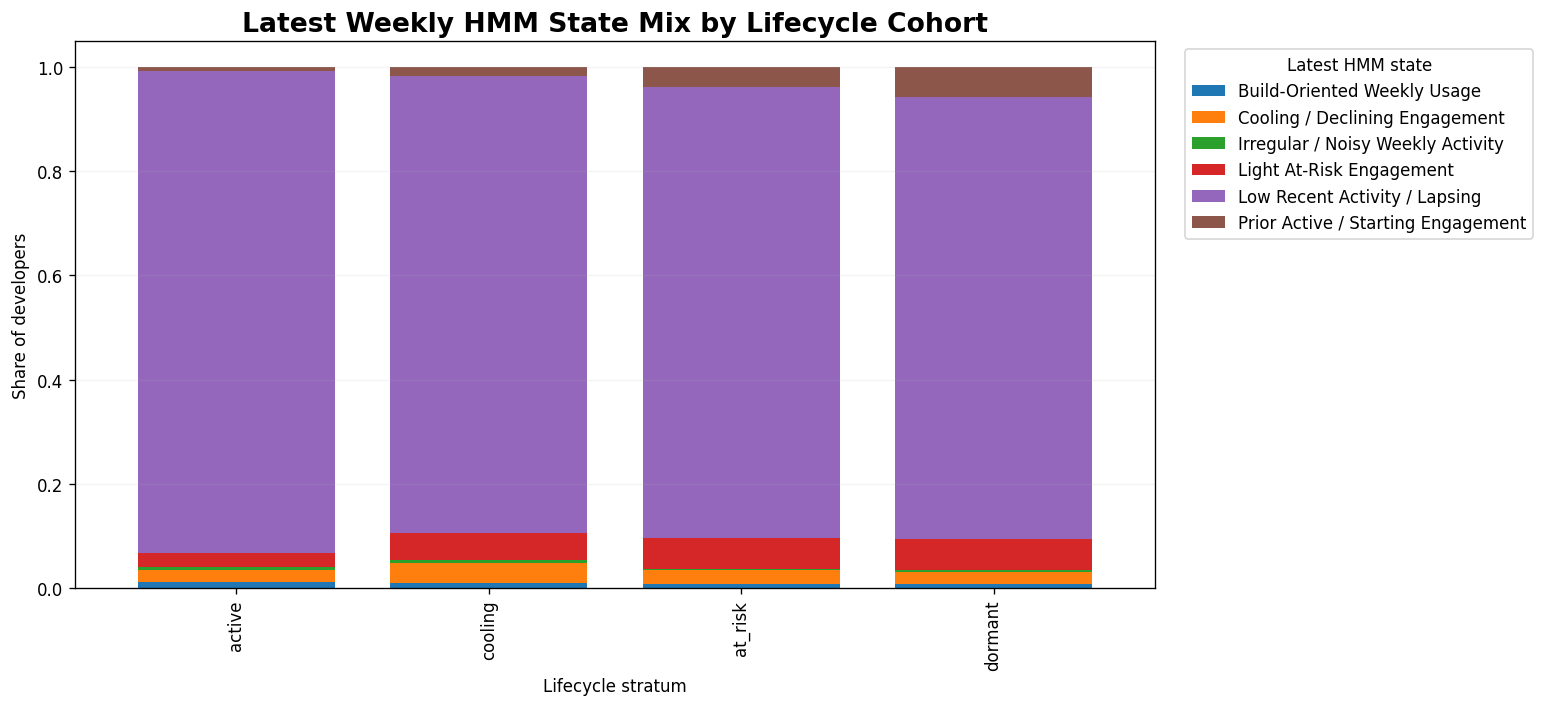

In [9]:
plot_df = lifecycle_signal.copy()
plot_df["share_within_stratum"] = plot_df["n_developers"] / plot_df.groupby("stratum")["n_developers"].transform("sum")

pivot = plot_df.pivot_table(
    index="stratum",
    columns="hmm_state_label",
    values="share_within_stratum",
    aggfunc="sum",
    fill_value=0,
)

order = [s for s in ["active", "cooling", "at_risk", "dormant", "unactivated"] if s in pivot.index]
pivot = pivot.loc[order]

fig, ax = plt.subplots(figsize=(13, 6))
pivot.plot(kind="bar", stacked=True, ax=ax, width=0.78)
ax.set_title("Latest Weekly HMM State Mix by Lifecycle Cohort", fontsize=16, weight="bold")
ax.set_xlabel("Lifecycle stratum")
ax.set_ylabel("Share of developers")
ax.legend(title="Latest HMM state", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
ax.grid(axis="y", alpha=0.15)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "hmm_latest_state_mix_by_lifecycle.png", bbox_inches="tight")
plt.show()

## 9. Presentation visual 2: Top journey archetypes

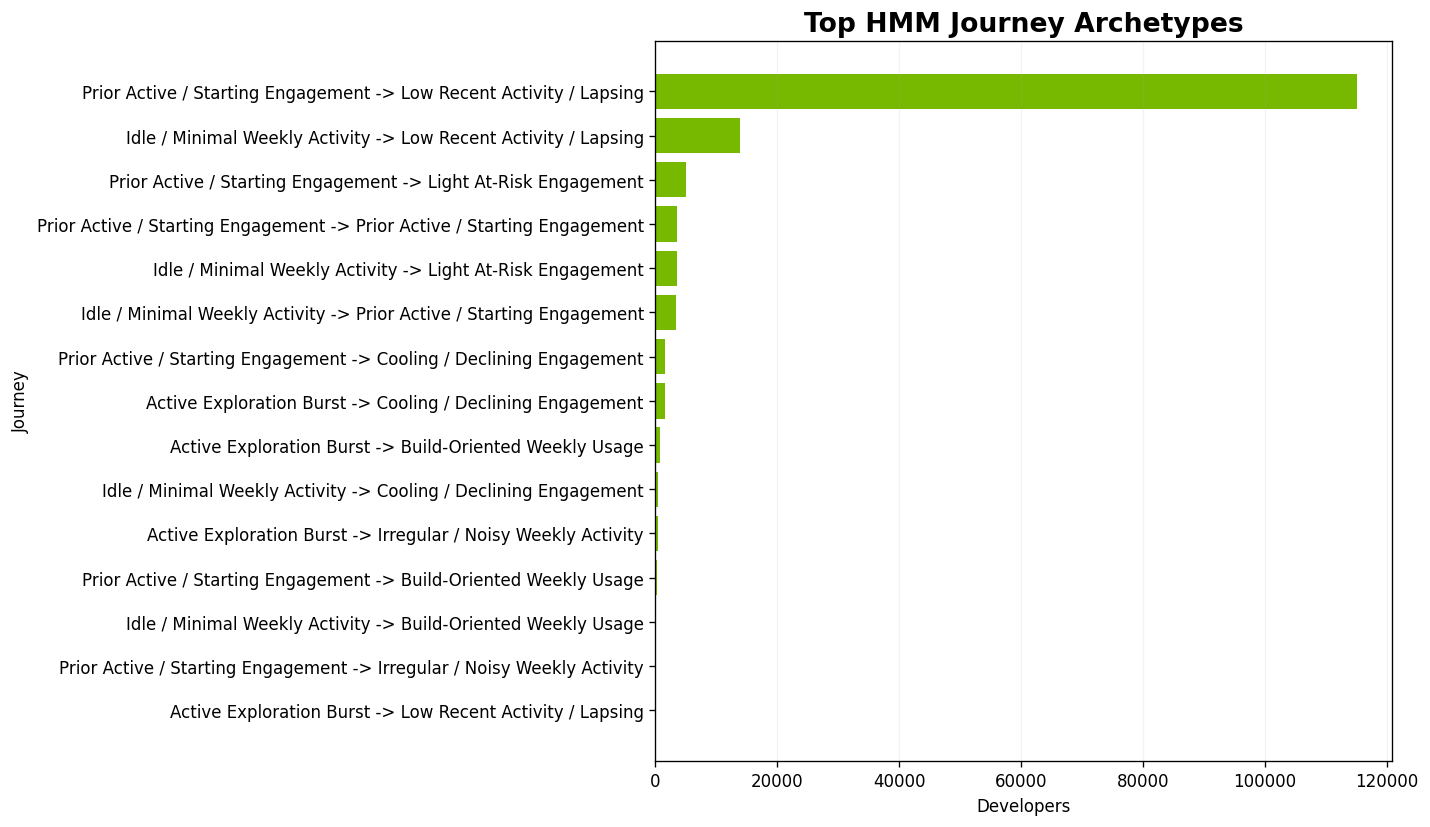

,journey_label,n_developers
15,Prior Active / Starting Engagement -> Low Rece...,115083
9,Idle / Minimal Weekly Activity -> Low Recent A...,13839
14,Prior Active / Starting Engagement -> Light At...,4993
16,Prior Active / Starting Engagement -> Prior Ac...,3613
8,Idle / Minimal Weekly Activity -> Light At-Ris...,3454
10,Idle / Minimal Weekly Activity -> Prior Active...,3352
12,Prior Active / Starting Engagement -> Cooling ...,1624
1,Active Exploration Burst -> Cooling / Declinin...,1610
0,Active Exploration Burst -> Build-Oriented Wee...,737
6,Idle / Minimal Weekly Activity -> Cooling / De...,488


In [10]:
top_journeys = (
    journey_summary
    .groupby("journey_label", as_index=False)["n_developers"]
    .sum()
    .sort_values("n_developers", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(top_journeys["journey_label"], top_journeys["n_developers"], color=NVIDIA_GREEN)
ax.invert_yaxis()
ax.set_title("Top HMM Journey Archetypes", fontsize=16, weight="bold")
ax.set_xlabel("Developers")
ax.set_ylabel("Journey")
ax.grid(axis="x", alpha=0.15)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "top_hmm_journey_archetypes.png", bbox_inches="tight")
plt.show()

display(top_journeys)

## 10. Presentation visual 3: HMM state by HDBSCAN stratum heatmap

This heatmap is usually easier to explain than a full cluster-level heatmap.

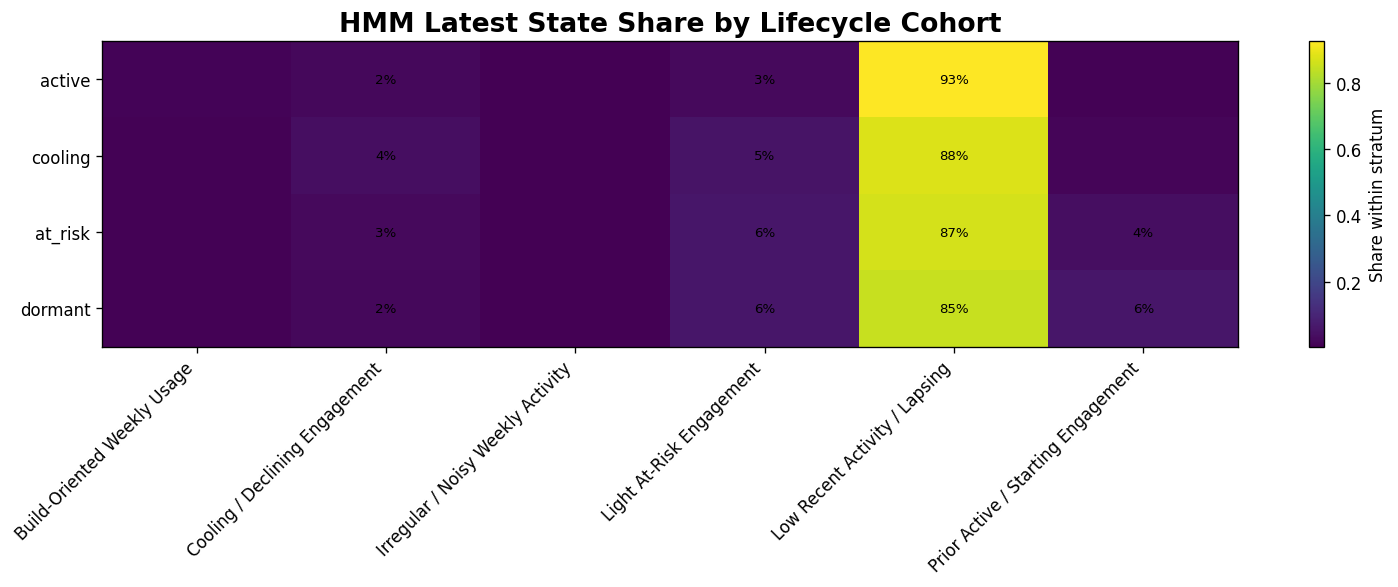

In [11]:
heat = lifecycle_signal.copy()
heat["share_within_stratum"] = heat["n_developers"] / heat.groupby("stratum")["n_developers"].transform("sum")
heat_pivot = heat.pivot_table(
    index="stratum",
    columns="hmm_state_label",
    values="share_within_stratum",
    fill_value=0,
    aggfunc="sum"
)
heat_pivot = heat_pivot.loc[[s for s in ["active", "cooling", "at_risk", "dormant"] if s in heat_pivot.index]]

fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(heat_pivot.values, aspect="auto")
ax.set_xticks(range(len(heat_pivot.columns)))
ax.set_xticklabels(heat_pivot.columns, rotation=45, ha="right")
ax.set_yticks(range(len(heat_pivot.index)))
ax.set_yticklabels(heat_pivot.index)
ax.set_title("HMM Latest State Share by Lifecycle Cohort", fontsize=16, weight="bold")

for i in range(heat_pivot.shape[0]):
    for j in range(heat_pivot.shape[1]):
        val = heat_pivot.values[i, j]
        if val > 0.02:
            ax.text(j, i, f"{val:.0%}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, label="Share within stratum")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "hmm_state_by_lifecycle_heatmap.png", bbox_inches="tight")
plt.show()

## 11. Create business signal flags

These flags are useful for asset impact and recommendations.

In [12]:
signals = con.execute("""
SELECT
    *,
    CASE
        WHEN stratum = 'active'
             AND hmm_state_label IN ('Low Recent Activity / Lapsing', 'Cooling / Declining Engagement')
        THEN 1 ELSE 0
    END AS early_warning_active_flag,

    CASE
        WHEN stratum IN ('at_risk', 'cooling')
             AND hmm_state_label IN ('Build-Oriented Weekly Usage', 'Prior Active / Starting Engagement')
        THEN 1 ELSE 0
    END AS recovery_candidate_flag,

    CASE
        WHEN stratum = 'dormant'
             AND hmm_state_label IN ('Prior Active / Starting Engagement', 'Build-Oriented Weekly Usage')
        THEN 1 ELSE 0
    END AS dormant_reactivation_signal_flag

FROM dev_hmm_hdbscan_alignment_v2
""").df()

con.register("signals_view", signals)
con.execute("""
CREATE OR REPLACE TABLE dev_hmm_business_signals_v2 AS
SELECT *
FROM signals_view
""")
con.unregister("signals_view")

print("Saved: dev_hmm_business_signals_v2")

display(signals[[
    "early_warning_active_flag",
    "recovery_candidate_flag",
    "dormant_reactivation_signal_flag"
]].sum().reset_index().rename(columns={"index": "signal", 0: "n_developers"}))

Saved: dev_hmm_business_signals_v2


,signal,n_developers
0,early_warning_active_flag,12260
1,recovery_candidate_flag,1903
2,dormant_reactivation_signal_flag,6005


## 12. Export HMM v2 outputs to parquet

In [13]:
EXPORT_DIR = Path("team_export_parquet")
EXPORT_DIR.mkdir(exist_ok=True)

hmm_v2_tables = [
    "dev_hmm_state_labels_v2",
    "dev_hmm_hdbscan_alignment_v2",
    "dev_hmm_lifecycle_signal_summary_v2",
    "dev_hmm_hdbscan_alignment_summary_v2",
    "dev_hmm_journey_archetype_summary_v2",
    "dev_hmm_business_signals_v2",
]

manifest = []
for table in hmm_v2_tables:
    out_path = EXPORT_DIR / f"{table}.parquet"
    n = con.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
    con.execute(f"""
        COPY {table}
        TO '{out_path.as_posix()}'
        (FORMAT PARQUET)
    """)
    manifest.append({"table_name": table, "rows": n, "path": out_path.as_posix()})
    print(f"Exported {table}: {n:,} rows -> {out_path}")

manifest_df = pd.DataFrame(manifest)
manifest_df.to_csv(EXPORT_DIR / "hmm_v2_export_manifest.csv", index=False)
display(manifest_df)

Exported dev_hmm_state_labels_v2: 8 rows -> team_export_parquet/dev_hmm_state_labels_v2.parquet
Exported dev_hmm_hdbscan_alignment_v2: 150,000 rows -> team_export_parquet/dev_hmm_hdbscan_alignment_v2.parquet
Exported dev_hmm_lifecycle_signal_summary_v2: 24 rows -> team_export_parquet/dev_hmm_lifecycle_signal_summary_v2.parquet
Exported dev_hmm_hdbscan_alignment_summary_v2: 71 rows -> team_export_parquet/dev_hmm_hdbscan_alignment_summary_v2.parquet
Exported dev_hmm_journey_archetype_summary_v2: 389 rows -> team_export_parquet/dev_hmm_journey_archetype_summary_v2.parquet
Exported dev_hmm_business_signals_v2: 150,000 rows -> team_export_parquet/dev_hmm_business_signals_v2.parquet


,table_name,rows,path
0,dev_hmm_state_labels_v2,8,team_export_parquet/dev_hmm_state_labels_v2.pa...
1,dev_hmm_hdbscan_alignment_v2,150000,team_export_parquet/dev_hmm_hdbscan_alignment_...
2,dev_hmm_lifecycle_signal_summary_v2,24,team_export_parquet/dev_hmm_lifecycle_signal_s...
3,dev_hmm_hdbscan_alignment_summary_v2,71,team_export_parquet/dev_hmm_hdbscan_alignment_...
4,dev_hmm_journey_archetype_summary_v2,389,team_export_parquet/dev_hmm_journey_archetype_...
5,dev_hmm_business_signals_v2,150000,team_export_parquet/dev_hmm_business_signals_v...


## 13. Close connection

In [14]:
con.close()
print("Done.")

Done.
